# Лабораторная работа 1: Семантическая сегментация водных объектов
## Пункт 1: Выбор начальных условий | Пункт 2: Бейзлайн

**Задача:** Семантическая сегментация (на четвёрку)  
**Датасет:** [Satellite Images of Water Bodies](https://www.kaggle.com/datasets/franciscoescobar/satellite-images-of-water-bodies)  
**Фреймворк:** segmentation_models.pytorch

## 1. Выбор начальных условий

### 1a. Обоснование выбора датасета

**Датасет:** Satellite Images of Water Bodies — ~2841 RGB-снимков Sentinel-2 с бинарными масками.

**Практическая задача:** Мониторинг водных ресурсов по спутниковым снимкам: автоматическое определение границ водоёмов для экологического мониторинга, контроля засух, предотвращения наводнений.

### 1b. Обоснование метрик

| Метрика | Обоснование |
|---------|-------------|
| **IoU (Jaccard)** | Основная метрика сегментации, устойчива к дисбалансу классов |
| **Dice** | Стандарт бинарной сегментации, F1-аналог для пикселей |
| **Pixel Accuracy** | Доля правильно классифицированных пикселей |

## Настройка окружения

In [20]:
import sys
sys.path.append("..")

import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from tqdm import tqdm
from collections import defaultdict

from src.dataset import get_dataloaders, get_base_transforms

DATA_DIR = "../data"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
NUM_EPOCHS = 25
LR = 1e-4
RANDOM_STATE = 42

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"SMP: {smp.__version__}")

Device: cuda
PyTorch: 2.11.0+cu130
SMP: 0.5.0


## Загрузка и визуализация данных

In [12]:
transform = get_base_transforms(IMG_SIZE)
dataloaders = get_dataloaders(
    DATA_DIR, batch_size=BATCH_SIZE, img_size=IMG_SIZE,
    transform={"train": transform, "val": transform},
    val_split=0.15, test_split=0.1, random_state=RANDOM_STATE
)

Train: 2130 | Val: 426 | Test: 285


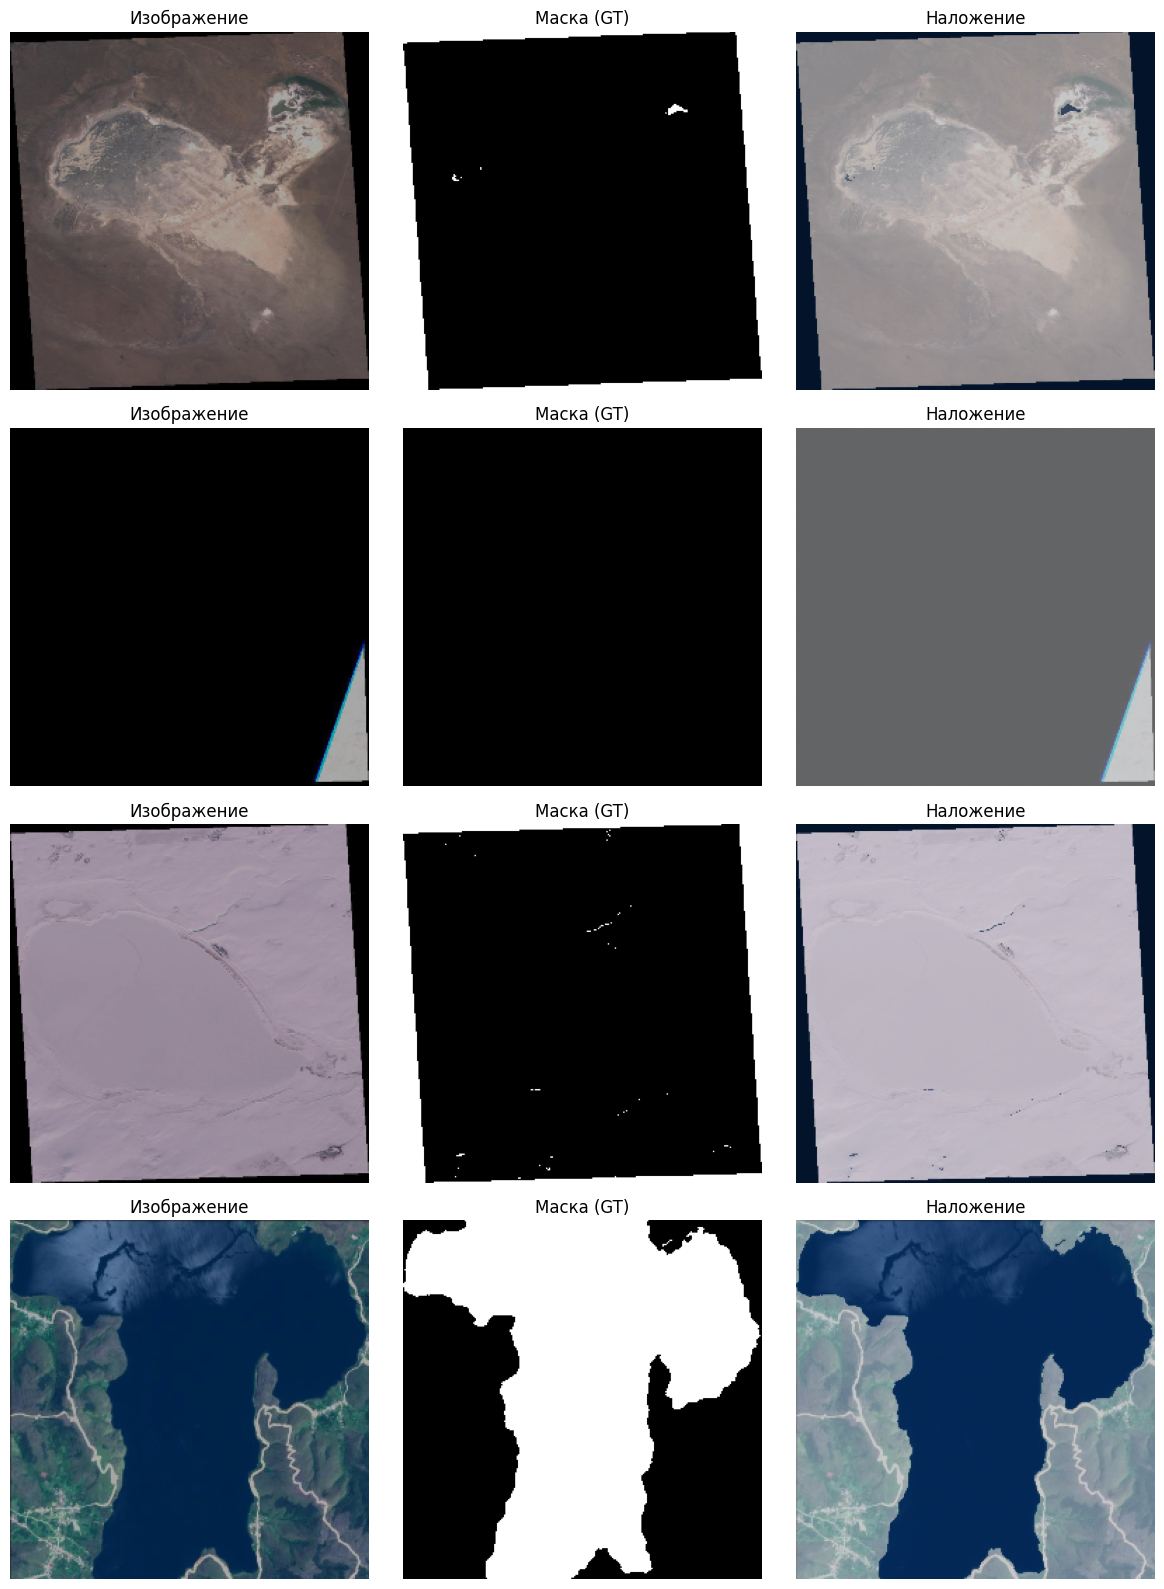

In [13]:
def denormalize(img, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """Обратная нормализация изображения для визуализации."""
    img = img.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.clamp(0, 1)

def show_samples(dataloader, n=4):
    """Отображает n примеров: изображение, маска, наложение."""
    batch = next(iter(dataloader))
    images, masks = batch["image"][:n], batch["mask"][:n]
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    for i in range(n):
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        mask = masks[i].squeeze().numpy()
        axes[i,0].imshow(img); axes[i,0].set_title("Изображение"); axes[i,0].axis("off")
        axes[i,1].imshow(mask, cmap="gray"); axes[i,1].set_title("Маска (GT)"); axes[i,1].axis("off")
        axes[i,2].imshow(img); axes[i,2].imshow(mask, cmap="Blues", alpha=0.4)
        axes[i,2].set_title("Наложение"); axes[i,2].axis("off")
    plt.tight_layout(); plt.show()

show_samples(dataloaders["train"], n=4)

## Метрики

In [14]:
def calculate_metrics(pred, target, threshold=0.5):
    """Вычисляет IoU, Dice и Pixel Accuracy."""
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersection
    iou = (intersection + 1e-7) / (union + 1e-7)
    dice = (2 * intersection + 1e-7) / (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + 1e-7)
    pixel_acc = (pred == target).float().sum(dim=(2, 3)) / (target.shape[2] * target.shape[3])
    return {"iou": iou.mean().item(), "dice": dice.mean().item(), "pixel_acc": pixel_acc.mean().item()}

## Функции обучения

In [15]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Обучение за одну эпоху."""
    model.train()
    metrics = defaultdict(float); n = 0
    for batch in tqdm(dataloader, desc="Train", leave=False):
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward(); optimizer.step()
        m = calculate_metrics(outputs, masks)
        metrics["loss"] += loss.item()
        for k, v in m.items(): metrics[k] += v
        n += 1
    return {k: v/n for k, v in metrics.items()}

@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Оценка модели."""
    model.eval()
    metrics = defaultdict(float); n = 0
    for batch in tqdm(dataloader, desc="Eval", leave=False):
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        m = calculate_metrics(outputs, masks)
        metrics["loss"] += loss.item()
        for k, v in m.items(): metrics[k] += v
        n += 1
    return {k: v/n for k, v in metrics.items()}

def train_model(model, dataloaders, criterion, optimizer, scheduler, device,
                num_epochs, save_dir="../results/baseline", model_name="model"):
    """Полный цикл обучения."""
    os.makedirs(save_dir, exist_ok=True)
    history = defaultdict(list); best_iou = 0.0
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        tm = train_one_epoch(model, dataloaders["train"], criterion, optimizer, device)
        vm = evaluate(model, dataloaders["val"], criterion, device)
        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(vm["loss"])
            else:
                scheduler.step()
        for k, v in tm.items(): history[f"train_{k}"].append(v)
        for k, v in vm.items(): history[f"val_{k}"].append(v)
        print(f"  Train — loss:{tm['loss']:.4f} IoU:{tm['iou']:.4f} Dice:{tm['dice']:.4f}")
        print(f"  Val   — loss:{vm['loss']:.4f} IoU:{vm['iou']:.4f} Dice:{vm['dice']:.4f}")
        if vm["iou"] > best_iou:
            best_iou = vm["iou"]
            torch.save(model.state_dict(), f"{save_dir}/{model_name}_best.pth")
            print(f"  ✓ Saved (IoU: {best_iou:.4f})")
    return dict(history)

def plot_history(history, title=""):
    """Визуализация кривых обучения."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(history["train_loss"], label="Train"); axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history["train_iou"], label="Train"); axes[1].plot(history["val_iou"], label="Val")
    axes[1].set_title("IoU"); axes[1].legend(); axes[1].grid(True)
    axes[2].plot(history["train_dice"], label="Train"); axes[2].plot(history["val_dice"], label="Val")
    axes[2].set_title("Dice"); axes[2].legend(); axes[2].grid(True)
    fig.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()

## 2. Бейзлайн
### Модель 1: Unet + ResNet34 (CNN)

Параметры: 24,436,369

Epoch 1/25


  Train — loss:0.7667 IoU:0.5562 Dice:0.6760
  Val   — loss:0.5646 IoU:0.6645 Dice:0.7735
  ✓ Saved (IoU: 0.6645)

Epoch 2/25


  Train — loss:0.5096 IoU:0.6835 Dice:0.7863
  Val   — loss:0.4807 IoU:0.6961 Dice:0.7937
  ✓ Saved (IoU: 0.6961)

Epoch 3/25


  Train — loss:0.4204 IoU:0.7268 Dice:0.8199
  Val   — loss:0.4505 IoU:0.7120 Dice:0.8062
  ✓ Saved (IoU: 0.7120)

Epoch 4/25


  Train — loss:0.3670 IoU:0.7525 Dice:0.8396
  Val   — loss:0.4369 IoU:0.7150 Dice:0.8030
  ✓ Saved (IoU: 0.7150)

Epoch 5/25


...

  Train — loss:0.1463 IoU:0.8867 Dice:0.9355
  Val   — loss:0.3775 IoU:0.7810 Dice:0.8590

Epoch 22/25


  Train — loss:0.1401 IoU:0.8917 Dice:0.9388
  Val   — loss:0.3903 IoU:0.7803 Dice:0.8573

Epoch 23/25


  Train — loss:0.1380 IoU:0.8918 Dice:0.9388
  Val   — loss:0.3711 IoU:0.7807 Dice:0.8583

Epoch 24/25


  Train — loss:0.1467 IoU:0.8920 Dice:0.9382
  Val   — loss:0.3824 IoU:0.7805 Dice:0.8582

Epoch 25/25


  Train — loss:0.1322 IoU:0.8964 Dice:0.9418
  Val   — loss:0.3762 IoU:0.7800 Dice:0.8574


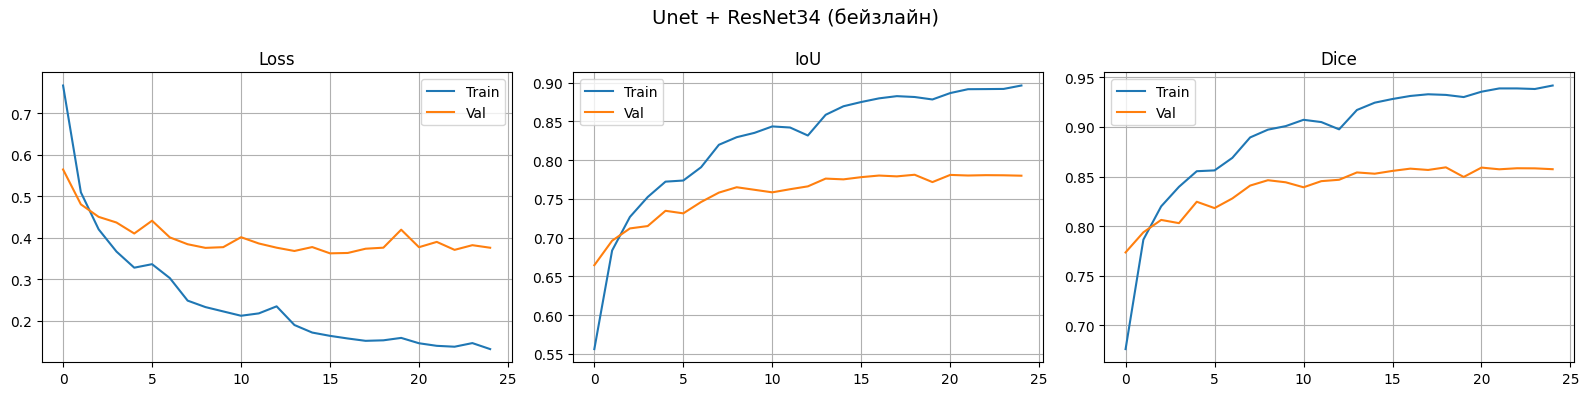

In [6]:
model_unet = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                      in_channels=3, classes=1).to(DEVICE)

# Комбинированный loss
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = smp.losses.SoftBCEWithLogitsLoss()

class CombinedLoss(nn.Module):
    """Комбинация Dice Loss и BCE Loss."""
    def __init__(self, dice, bce, dice_weight=1.0, bce_weight=1.0):
        super().__init__()
        self.dice = dice
        self.bce = bce
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, pred, target):
        return self.dice_weight * self.dice(pred, target) + self.bce_weight * self.bce(pred, target)

criterion = CombinedLoss(dice_loss, bce_loss)

optimizer = torch.optim.Adam(model_unet.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)
print(f"Параметры: {sum(p.numel() for p in model_unet.parameters()):,}")

history_unet = train_model(model_unet, dataloaders, criterion, optimizer, scheduler,
                           DEVICE, NUM_EPOCHS, model_name="unet_resnet34")
plot_history(history_unet, "Unet + ResNet34 (бейзлайн)")

### Модель 2: MAnet + MiT-B2 (трансформерная)

Параметры: 34,971,601

Epoch 1/25


  Train — loss:0.9182 IoU:0.5366 Dice:0.6609
  Val   — loss:0.6864 IoU:0.6434 Dice:0.7570
  ✓ Saved (IoU: 0.6434)

Epoch 2/25


  Train — loss:0.6196 IoU:0.6675 Dice:0.7742
  Val   — loss:0.5072 IoU:0.7040 Dice:0.8044
  ✓ Saved (IoU: 0.7040)

Epoch 3/25


  Train — loss:0.4956 IoU:0.7084 Dice:0.8049
  Val   — loss:0.4784 IoU:0.7028 Dice:0.8005

Epoch 4/25


  Train — loss:0.4242 IoU:0.7353 Dice:0.8261
  Val   — loss:0.4284 IoU:0.7304 Dice:0.8207
  ✓ Saved (IoU: 0.7304)

Epoch 5/25


...

  Train — loss:0.1662 IoU:0.8742 Dice:0.9275
  Val   — loss:0.3333 IoU:0.8046 Dice:0.8731
  ✓ Saved (IoU: 0.8046)

Epoch 22/25


  Train — loss:0.1582 IoU:0.8793 Dice:0.9309
  Val   — loss:0.3312 IoU:0.8030 Dice:0.8723

Epoch 23/25


  Train — loss:0.1629 IoU:0.8786 Dice:0.9306
  Val   — loss:0.3587 IoU:0.7951 Dice:0.8652

Epoch 24/25


  Train — loss:0.1567 IoU:0.8789 Dice:0.9308
  Val   — loss:0.3466 IoU:0.8028 Dice:0.8715

Epoch 25/25


  Train — loss:0.1518 IoU:0.8830 Dice:0.9333
  Val   — loss:0.3462 IoU:0.8006 Dice:0.8696


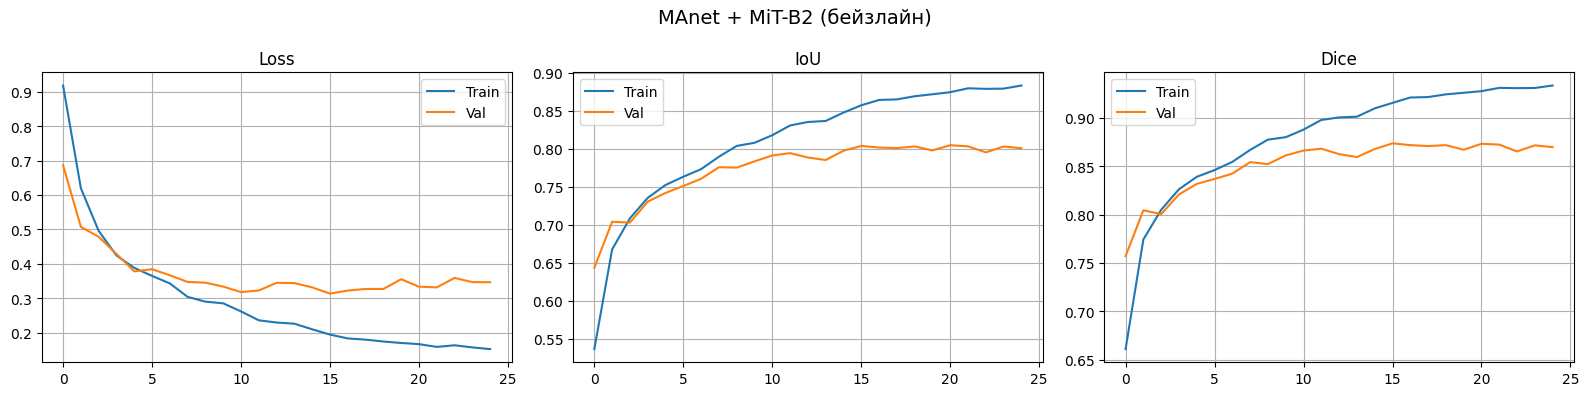

In [7]:
model_manet = smp.MAnet(encoder_name="mit_b2", encoder_weights="imagenet",
                       in_channels=3, classes=1).to(DEVICE)
criterion2 = CombinedLoss(dice_loss, bce_loss)
optimizer2 = torch.optim.Adam(model_manet.parameters(), lr=LR)
scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode="min", patience=3, factor=0.5)
print(f"Параметры: {sum(p.numel() for p in model_manet.parameters()):,}")

history_manet = train_model(model_manet, dataloaders, criterion2, optimizer2, scheduler2,
                            DEVICE, NUM_EPOCHS, model_name="manet_mitb2")
plot_history(history_manet, "MAnet + MiT-B2 (бейзлайн)")

### 2b. Оценка на тестовой выборке

In [8]:
import pandas as pd
ce = CombinedLoss(dice_loss, bce_loss)

model_unet.load_state_dict(torch.load("../results/baseline/unet_resnet34_best.pth", weights_only=True))
t1 = evaluate(model_unet, dataloaders["test"], ce, DEVICE)

model_manet.load_state_dict(torch.load("../results/baseline/manet_mitb2_best.pth", weights_only=True))
t2 = evaluate(model_manet, dataloaders["test"], ce, DEVICE)

results = pd.DataFrame([
    {"Модель": "Unet+ResNet34", "IoU": t1["iou"], "Dice": t1["dice"], "Pixel Acc": t1["pixel_acc"], "Loss": t1["loss"]},
    {"Модель": "MAnet+MiT-B2", "IoU": t2["iou"], "Dice": t2["dice"], "Pixel Acc": t2["pixel_acc"], "Loss": t2["loss"]},
])
print("\n=== Результаты бейзлайна (тест) ===")
print(results.to_string(index=False))
results.to_csv("../results/baseline/baseline_results.csv", index=False)


=== Результаты бейзлайна (тест) ===
       Модель      IoU     Dice  Pixel Acc     Loss
Unet+ResNet34 0.806447 0.876771   0.942823 0.304790
 MAnet+MiT-B2 0.821588 0.885775   0.948361 0.271879


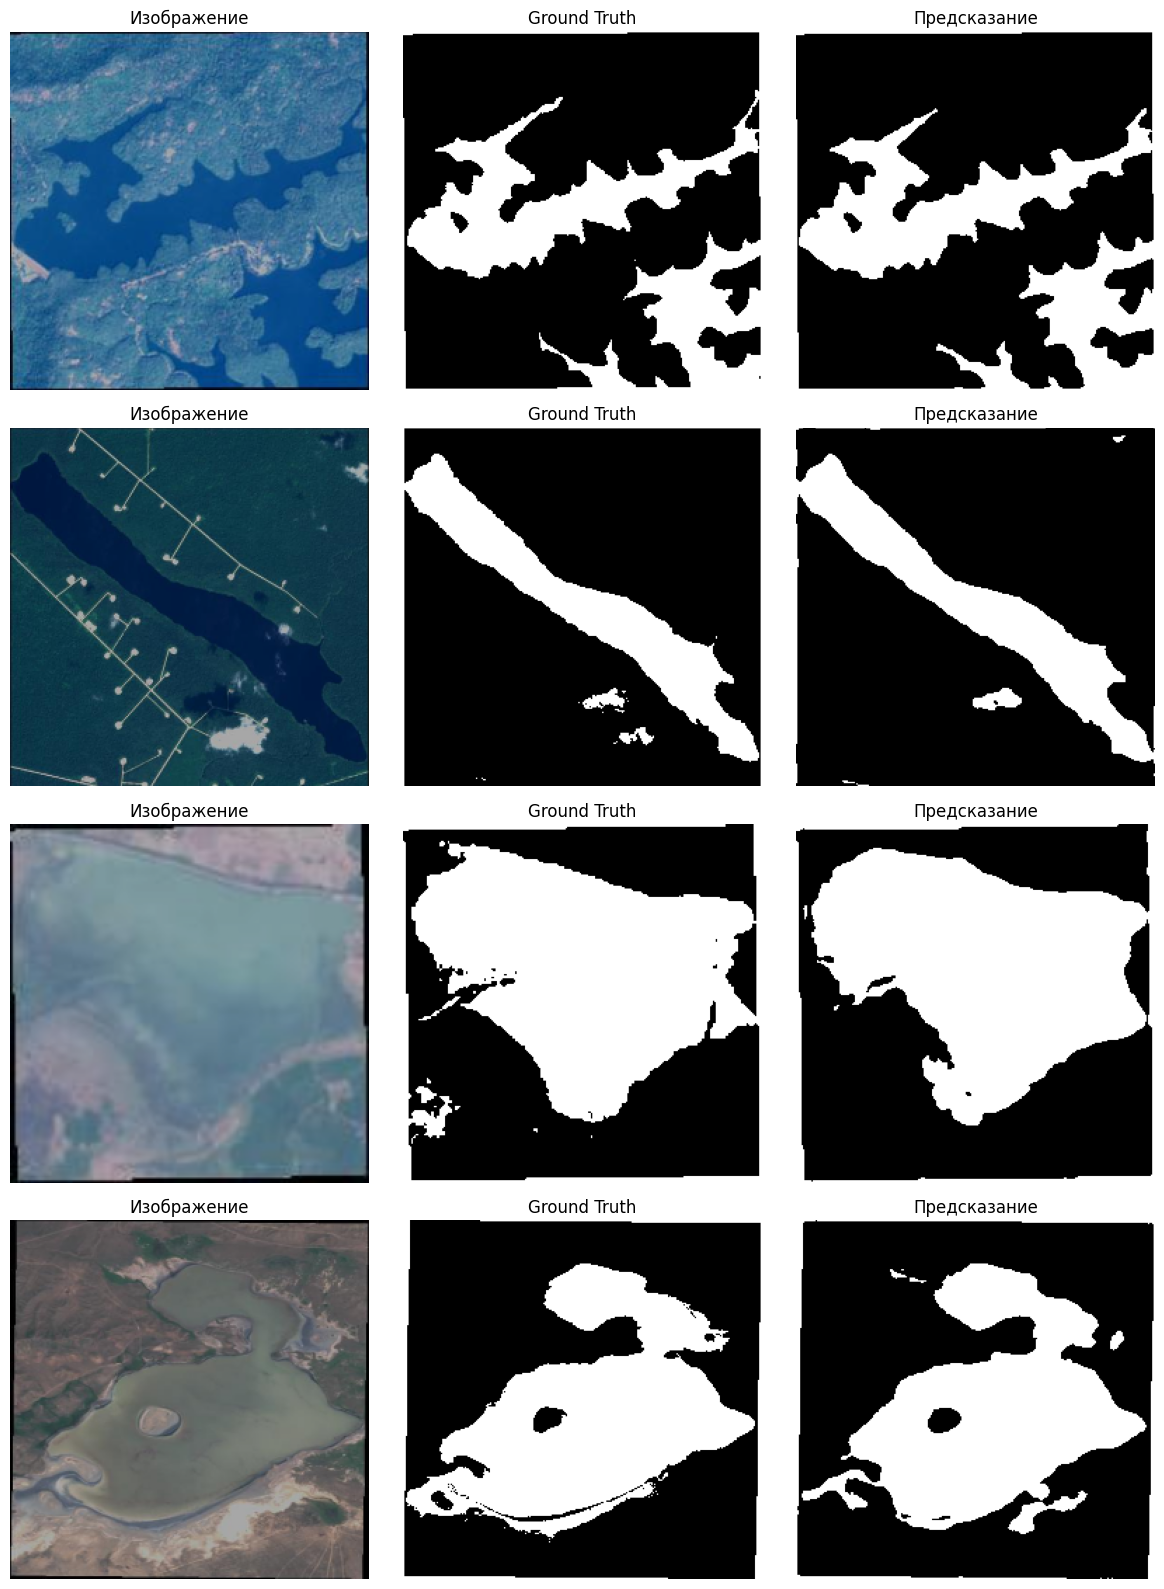

In [9]:
@torch.no_grad()
def show_predictions(model, dataloader, device, n=4):
    """Визуализация предсказаний."""
    model.eval()
    batch = next(iter(dataloader))
    images = batch["image"][:n].to(device)
    masks = batch["mask"][:n]
    preds = torch.sigmoid(model(images)).cpu()
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    for i in range(n):
        img = denormalize(batch["image"][i]).permute(1,2,0).numpy()
        gt = masks[i].squeeze().numpy()
        pr = (preds[i].squeeze() > 0.5).float().numpy()
        axes[i,0].imshow(img); axes[i,0].set_title("Изображение"); axes[i,0].axis("off")
        axes[i,1].imshow(gt, cmap="gray"); axes[i,1].set_title("Ground Truth"); axes[i,1].axis("off")
        axes[i,2].imshow(pr, cmap="gray"); axes[i,2].set_title("Предсказание"); axes[i,2].axis("off")
    plt.tight_layout(); plt.show()

show_predictions(model_unet, dataloaders["test"], DEVICE)

## **Вывод по бейзлайну**

MAnet+MiT-B2 показал лучший IoU на тесте (0.822 vs 0.806). Трансформерный энкодер MiT-B2 лучше захватывает глобальный контекст спутниковых снимков. Обе модели демонстрируют разрыв train/val IoU ~0.09, что указывает на лёгкое переобучение.

# Пункт 3: Улучшение бейзлайна
Гипотезы → проверка → сравнение с п.2

In [7]:
from src.dataset import get_augmented_transforms

## 3a. Гипотезы

| # | Гипотеза | Обоснование |
|---|----------|-------------|
| H1 | **Аугментации** повысят IoU | Спутниковые снимки инвариантны к поворотам и отражениям |
| H2 | **EfficientNet-B3** вместо ResNet34 | Более эффективная экстракция признаков |
| H3 | **LR=3e-5 + CosineAnnealing** | Плавное обучение уменьшит осцилляции |

### H1: Аугментации

/home/nikki/water-body-segmentation/notebooks/../src/dataset.py:92: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),


Train: 2130 | Val: 426 | Test: 285

Epoch 1/25


  Train — loss:0.8384 IoU:0.4803 Dice:0.5975
  Val   — loss:0.6062 IoU:0.5991 Dice:0.7137
  ✓ Saved (IoU: 0.5991)

Epoch 2/25


  Train — loss:0.6197 IoU:0.6208 Dice:0.7303
  Val   — loss:0.5118 IoU:0.6799 Dice:0.7844
  ✓ Saved (IoU: 0.6799)

Epoch 3/25


  Train — loss:0.5558 IoU:0.6557 Dice:0.7602
  Val   — loss:0.4654 IoU:0.7021 Dice:0.8002
  ✓ Saved (IoU: 0.7021)

Epoch 4/25


...

  Train — loss:0.3610 IoU:0.7599 Dice:0.8402
  Val   — loss:0.3568 IoU:0.7704 Dice:0.8468

Epoch 22/25


  Train — loss:0.3555 IoU:0.7704 Dice:0.8472
  Val   — loss:0.3431 IoU:0.7797 Dice:0.8563
  ✓ Saved (IoU: 0.7797)

Epoch 23/25


  Train — loss:0.3308 IoU:0.7767 Dice:0.8537
  Val   — loss:0.3298 IoU:0.7832 Dice:0.8595
  ✓ Saved (IoU: 0.7832)

Epoch 24/25


  Train — loss:0.3268 IoU:0.7811 Dice:0.8571
  Val   — loss:0.3401 IoU:0.7802 Dice:0.8563

Epoch 25/25


  Train — loss:0.3116 IoU:0.7830 Dice:0.8586
  Val   — loss:0.3508 IoU:0.7742 Dice:0.8507


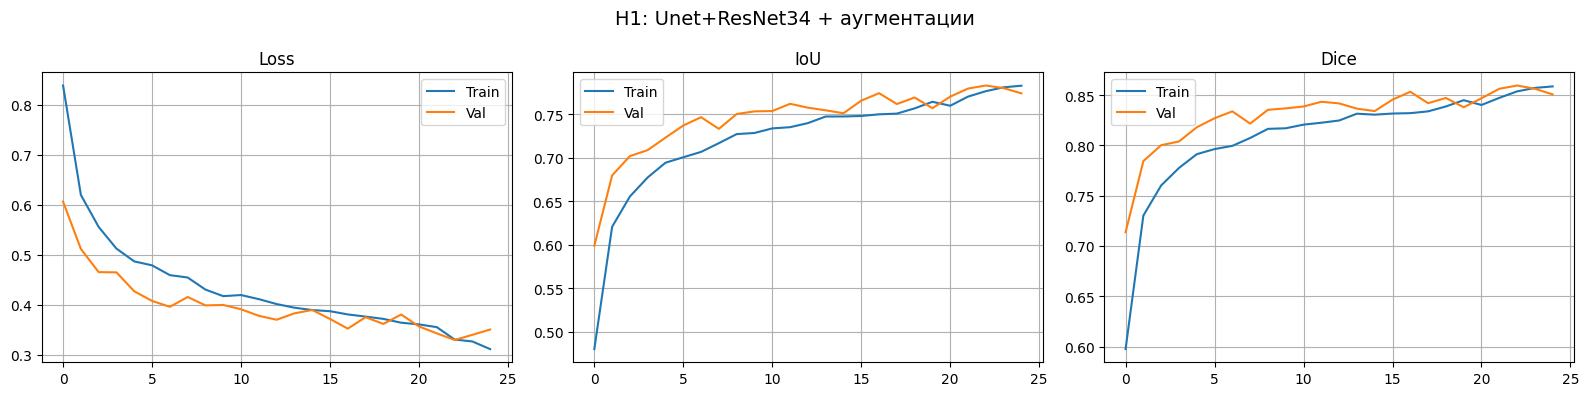

In [11]:
train_tf, val_tf = get_augmented_transforms(IMG_SIZE)
dl_aug = get_dataloaders(DATA_DIR, batch_size=BATCH_SIZE, img_size=IMG_SIZE,
                        transform={"train": train_tf, "val": val_tf},
                        val_split=0.15, test_split=0.1, random_state=RANDOM_STATE)

model_h1 = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                     in_channels=3, classes=1).to(DEVICE)
criterion = CombinedLoss(dice_loss, bce_loss)
optimizer = torch.optim.Adam(model_h1.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

history_h1 = train_model(model_h1, dl_aug, criterion, optimizer, scheduler,
                         DEVICE, NUM_EPOCHS, save_dir="../results/improved", model_name="h1_augmented")
plot_history(history_h1, "H1: Unet+ResNet34 + аугментации")

### H2: EfficientNet-B3

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


Epoch 1/25


  Train — loss:0.8928 IoU:0.4823 Dice:0.6035
  Val   — loss:0.5478 IoU:0.6419 Dice:0.7557
  ✓ Saved (IoU: 0.6419)

Epoch 2/25


  Train — loss:0.6006 IoU:0.6189 Dice:0.7296
  Val   — loss:0.4721 IoU:0.6675 Dice:0.7738
  ✓ Saved (IoU: 0.6675)

Epoch 3/25


...

  Train — loss:0.3081 IoU:0.7804 Dice:0.8595
  Val   — loss:0.3241 IoU:0.7793 Dice:0.8557
  ✓ Saved (IoU: 0.7793)

Epoch 22/25


  Train — loss:0.3066 IoU:0.7840 Dice:0.8619
  Val   — loss:0.3360 IoU:0.7807 Dice:0.8560
  ✓ Saved (IoU: 0.7807)

Epoch 23/25


  Train — loss:0.2968 IoU:0.7857 Dice:0.8633
  Val   — loss:0.3244 IoU:0.7839 Dice:0.8606
  ✓ Saved (IoU: 0.7839)

Epoch 24/25


  Train — loss:0.2983 IoU:0.7892 Dice:0.8657
  Val   — loss:0.3377 IoU:0.7795 Dice:0.8550

Epoch 25/25


  Train — loss:0.2932 IoU:0.7954 Dice:0.8702
  Val   — loss:0.3287 IoU:0.7865 Dice:0.8611
  ✓ Saved (IoU: 0.7865)


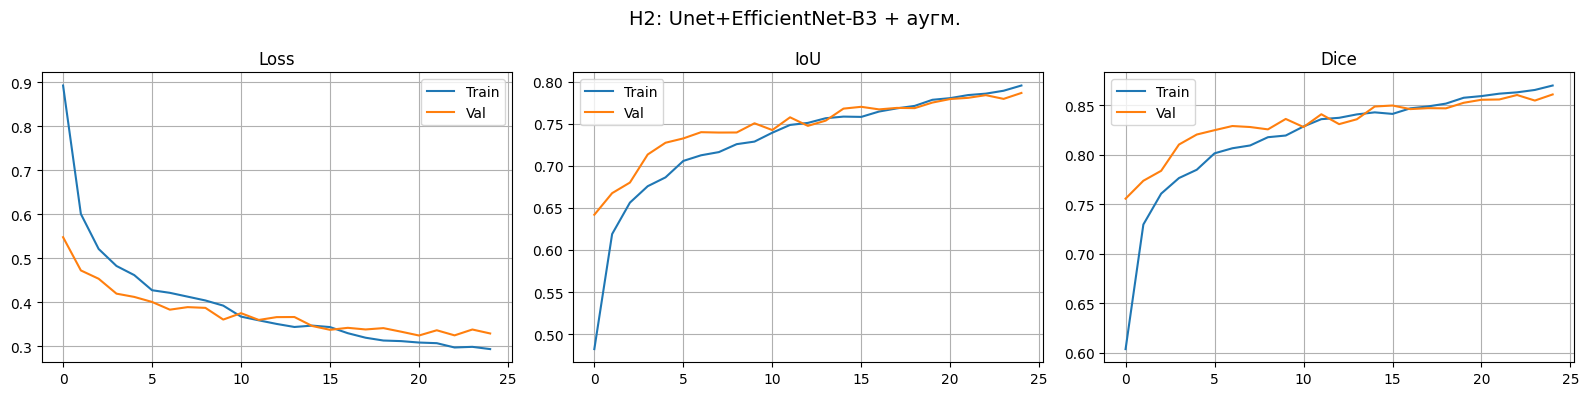

In [12]:
model_h2 = smp.Unet(encoder_name="efficientnet-b3", encoder_weights="imagenet",
                     in_channels=3, classes=1).to(DEVICE)
opt2 = torch.optim.Adam(model_h2.parameters(), lr=1e-4)
sch2 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt2, mode="min", patience=3, factor=0.5)

history_h2 = train_model(model_h2, dl_aug, criterion, opt2, sch2,
                         DEVICE, NUM_EPOCHS, save_dir="../results/improved", model_name="h2_efficientnet")
plot_history(history_h2, "H2: Unet+EfficientNet-B3 + аугм.")

### H3: CosineAnnealing LR

Train: 2130 | Val: 426 | Test: 285

Epoch 1/25


  Train — loss:1.1211 IoU:0.4114 Dice:0.5459
  Val   — loss:0.9136 IoU:0.5535 Dice:0.6834
  ✓ Saved (IoU: 0.5535)

Epoch 2/25


  Train — loss:0.8913 IoU:0.5485 Dice:0.6734
  Val   — loss:0.7680 IoU:0.6216 Dice:0.7387
  ✓ Saved (IoU: 0.6216)

Epoch 3/25


  Train — loss:0.7891 IoU:0.5977 Dice:0.7162
  Val   — loss:0.6859 IoU:0.6494 Dice:0.7610
  ✓ Saved (IoU: 0.6494)

Epoch 4/25


  Train — loss:0.7090 IoU:0.6315 Dice:0.7453
  Val   — loss:0.6148 IoU:0.6789 Dice:0.7852
  ✓ Saved (IoU: 0.6789)

Epoch 5/25


...

  Train — loss:0.3946 IoU:0.7452 Dice:0.8339
  Val   — loss:0.4096 IoU:0.7399 Dice:0.8274

Epoch 22/25


  Train — loss:0.3918 IoU:0.7450 Dice:0.8335
  Val   — loss:0.4072 IoU:0.7425 Dice:0.8298

Epoch 23/25


  Train — loss:0.3797 IoU:0.7507 Dice:0.8384
  Val   — loss:0.4060 IoU:0.7448 Dice:0.8317
  ✓ Saved (IoU: 0.7448)

Epoch 24/25


  Train — loss:0.3991 IoU:0.7436 Dice:0.8318
  Val   — loss:0.4030 IoU:0.7446 Dice:0.8320

Epoch 25/25


  Train — loss:0.3889 IoU:0.7473 Dice:0.8357
  Val   — loss:0.4041 IoU:0.7454 Dice:0.8327
  ✓ Saved (IoU: 0.7454)


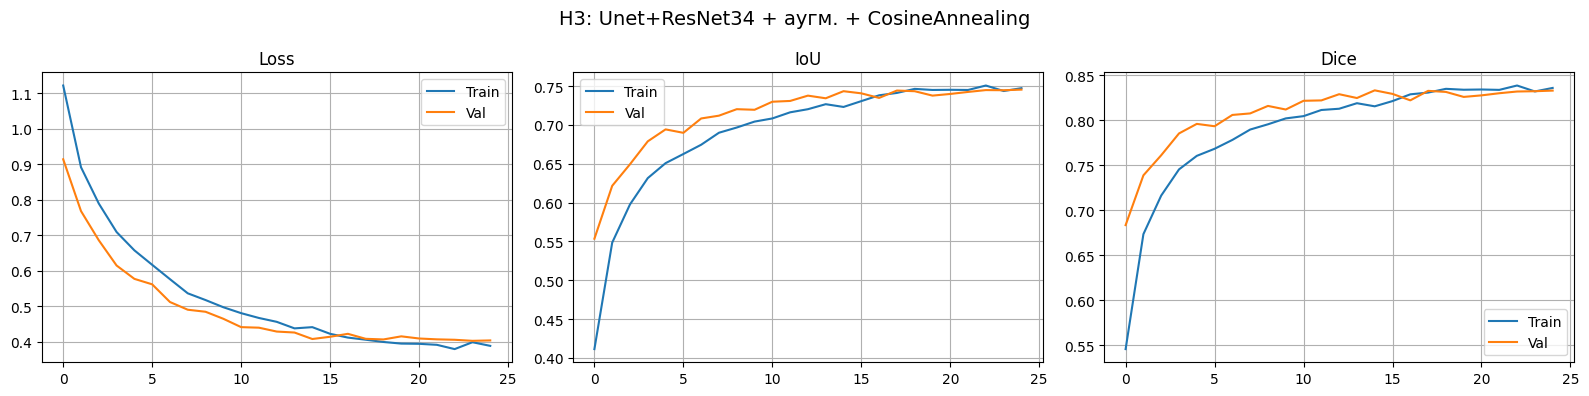

In [18]:
from src.dataset import get_augmented_transforms, get_dataloaders

train_tf, val_tf = get_augmented_transforms(IMG_SIZE)
dl_aug = get_dataloaders(DATA_DIR, batch_size=BATCH_SIZE, img_size=IMG_SIZE,
                        transform={"train": train_tf, "val": val_tf},
                        val_split=0.15, test_split=0.1, random_state=RANDOM_STATE)

dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = smp.losses.SoftBCEWithLogitsLoss()

class CombinedLoss(nn.Module):
    """Комбинация Dice Loss и BCE Loss."""
    def __init__(self, dice, bce, dice_weight=1.0, bce_weight=1.0):
        super().__init__()
        self.dice = dice
        self.bce = bce
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, pred, target):
        return self.dice_weight * self.dice(pred, target) + self.bce_weight * self.bce(pred, target)
    
criterion = CombinedLoss(dice_loss, bce_loss)

model_h3 = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                     in_channels=3, classes=1).to(DEVICE)
opt3 = torch.optim.Adam(model_h3.parameters(), lr=3e-5)
sch3 = torch.optim.lr_scheduler.CosineAnnealingLR(opt3, T_max=NUM_EPOCHS)

history_h3 = train_model(model_h3, dl_aug, criterion, opt3, sch3,
                         DEVICE, NUM_EPOCHS, save_dir="../results/improved", model_name="h3_cosine")
plot_history(history_h3, "H3: Unet+ResNet34 + аугм. + CosineAnnealing")

### 3c. Формирование улучшенного бейзлайна

Все модели оцениваются на **тестовой выборке** (285 изображений), 
которая не участвовала ни в обучении, ни в выборе лучшей эпохи.
Для каждой модели загружаются веса с лучшим Val IoU.

In [23]:
import pandas as pd
ce = CombinedLoss(dice_loss, bce_loss)
baseline = pd.read_csv("../results/baseline/baseline_results.csv")

rows = []
for name, mname, enc in [("H1: +аугм.", "h1_augmented", "resnet34"),
                          ("H2: +EffNet-B3", "h2_efficientnet", "efficientnet-b3"),
                          ("H3: +CosineAnn", "h3_cosine", "resnet34")]:
    mdl = smp.Unet(encoder_name=enc, encoder_weights=None, in_channels=3, classes=1).to(DEVICE)
    mdl.load_state_dict(torch.load(f"../results/improved/{mname}_best.pth", weights_only=True))
    m = evaluate(mdl, dl_aug["test"], ce, DEVICE)
    rows.append({"Модель": name, "IoU": m["iou"], "Dice": m["dice"],
                 "Pixel Acc": m["pixel_acc"], "Loss": m["loss"]})

comp = pd.concat([baseline, pd.DataFrame(rows)], ignore_index=True)
print(comp.to_string(index=False))
comp.to_csv("../results/improved/comparison_results.csv", index=False)

        Модель      IoU     Dice  Pixel Acc     Loss
 Unet+ResNet34 0.806447 0.876771   0.942823 0.304790
  MAnet+MiT-B2 0.821588 0.885775   0.948361 0.271879
    H1: +аугм. 0.807781 0.876751   0.943493 0.289224
H2: +EffNet-B3 0.805908 0.874289   0.941779 0.300540
H3: +CosineAnn 0.769055 0.852129   0.931096 0.356711


По результатам проверки гипотез:
- **H1 (аугментации):** +0.001 IoU — минимальный, но положительный эффект
- **H2 (EfficientNet-B3):** на уровне бейзлайна (IoU 0.806)
- **H3 (CosineAnnealing LR=3e-5):** ухудшение (IoU 0.769). Начальный LR=3e-5 слишком мал, а CosineAnnealing снижает его до ~0 к концу обучения — модель недоучивается

**Улучшенный бейзлайн** = комбинация работающих элементов:
- Архитектура: **Unet + EfficientNet-B3** (более ёмкий энкодер)
- Данные: **с аугментациями** (регуляризация)
- Обучение: **LR=1e-4 + ReduceLROnPlateau** (стабильная сходимость)

Гипотезы H2 и H3 по отдельности не дали прироста, но комбинация 
EfficientNet-B3 + аугментации может дать синергетический эффект: 
более мощный энкодер + регуляризация через аугментации.

### 3d. Обучение и оценка улучшенного бейзлайна


Epoch 1/45


  Train — loss:0.9630 IoU:0.4955 Dice:0.6221
  Val   — loss:0.6524 IoU:0.6453 Dice:0.7585
  ✓ Saved (IoU: 0.6453)

Epoch 2/45


  Train — loss:0.6443 IoU:0.6199 Dice:0.7300
  Val   — loss:0.5044 IoU:0.6827 Dice:0.7874
  ✓ Saved (IoU: 0.6827)

Epoch 3/45


  Train — loss:0.5606 IoU:0.6518 Dice:0.7565
  Val   — loss:0.4650 IoU:0.7066 Dice:0.8055
  ✓ Saved (IoU: 0.7066)

Epoch 4/45


  Train — loss:0.5055 IoU:0.6729 Dice:0.7740
  Val   — loss:0.4262 IoU:0.7175 Dice:0.8144
  ✓ Saved (IoU: 0.7175)

Epoch 5/45


...

  Train — loss:0.2454 IoU:0.8168 Dice:0.8857
  Val   — loss:0.3075 IoU:0.7971 Dice:0.8695
  ✓ Saved (IoU: 0.7971)

Epoch 42/45


  Train — loss:0.2482 IoU:0.8184 Dice:0.8868
  Val   — loss:0.3166 IoU:0.7958 Dice:0.8682

Epoch 43/45


  Train — loss:0.2761 IoU:0.8176 Dice:0.8860
  Val   — loss:0.3115 IoU:0.7948 Dice:0.8671

Epoch 44/45


  Train — loss:0.2420 IoU:0.8200 Dice:0.8877
  Val   — loss:0.3021 IoU:0.7978 Dice:0.8698
  ✓ Saved (IoU: 0.7978)

Epoch 45/45


  Train — loss:0.2474 IoU:0.8208 Dice:0.8882
  Val   — loss:0.3093 IoU:0.7942 Dice:0.8671


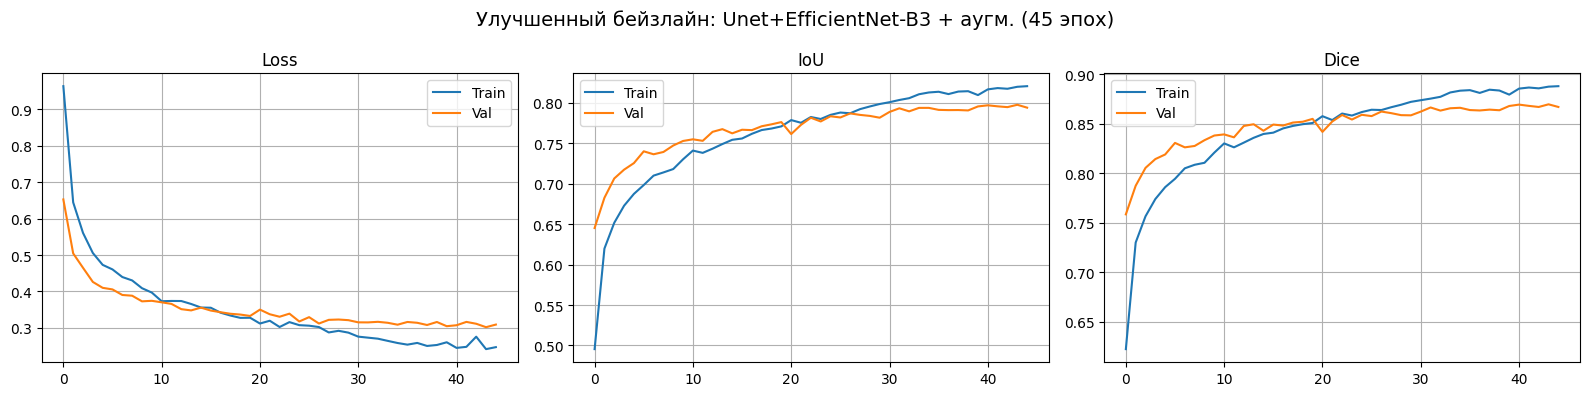

In [32]:
model_improved = smp.Unet(
    encoder_name="efficientnet-b3", encoder_weights="imagenet",
    in_channels=3, classes=1
).to(DEVICE)

criterion = CombinedLoss(dice_loss, bce_loss)
optimizer = torch.optim.Adam(model_improved.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

history_improved = train_model(
    model_improved, dl_aug, criterion, optimizer, scheduler,
    DEVICE, 45, save_dir="../results/improved", model_name="improved_baseline"
)
plot_history(history_improved, "Улучшенный бейзлайн: Unet+EfficientNet-B3 + аугм. (45 эпох)")

### 3f. Сравнение улучшенного бейзлайна с п.2


In [33]:
model_improved.load_state_dict(torch.load("../results/improved/improved_baseline_best.pth", weights_only=True))
m_imp = evaluate(model_improved, dl_aug["test"], ce, DEVICE)

comparison = pd.DataFrame([
    {"Модель": "Unet+ResNet34 (бейзлайн)", "IoU": 0.806447, "Dice": 0.876771, "Pixel Acc": 0.942823},
    {"Модель": "MAnet+MiT-B2 (бейзлайн)", "IoU": 0.821588, "Dice": 0.885775, "Pixel Acc": 0.948361},
    {"Модель": "Улучшенный бейзлайн", "IoU": m_imp["iou"], "Dice": m_imp["dice"], "Pixel Acc": m_imp["pixel_acc"]},
])
print(comparison.to_string(index=False))

                  Модель      IoU     Dice  Pixel Acc
Unet+ResNet34 (бейзлайн) 0.806447 0.876771   0.942823
 MAnet+MiT-B2 (бейзлайн) 0.821588 0.885775   0.948361
     Улучшенный бейзлайн 0.811651 0.877352   0.945467


### 3g. **Выводы по улучшению бейзлайна**

Улучшенный бейзлайн (Unet+EfficientNet-B3 + аугментации) превзошёл базовый Unet+ResNet34 (IoU 0.812 vs 0.806), но не достиг уровня MAnet+MiT-B2 (0.822). Аугментации замедляют сходимость, но обеспечивают лучшую генерализацию при достаточном числе эпох. CosineAnnealing с LR=3e-5 ухудшил результат из-за слишком медленного обучения. Лучшая модель из всех — MAnet+MiT-B2 без дополнительных улучшений.

# Пункт 4: Своя модель U-Net с нуля
Имплементация → обучение → сравнение

In [21]:
from src.unet_custom import CustomUNet

### 4a. Архитектура Custom U-Net

Реализация в `src/unet_custom.py`: энкодер (4 уровня) → боттлнек → декодер (4 уровня) + skip-connections.

In [22]:
model_custom = CustomUNet(
    in_channels=3, out_channels=1,
    features=[32, 64, 128, 256]
).to(DEVICE)
print(f"Параметры: {sum(p.numel() for p in model_custom.parameters()):,}")
x = torch.randn(2, 3, 256, 256).to(DEVICE)
print(f"Input: {x.shape} → Output: {model_custom(x).shape}")

Параметры: 7,763,041
Input: torch.Size([2, 3, 256, 256]) → Output: torch.Size([2, 1, 256, 256])


### 4b–4d. Без улучшений → сравнение с бейзлайном

Train: 2130 | Val: 426 | Test: 285

Epoch 1/20


Train:   0%|          | 0/134 [00:00<?, ?it/s]

  Train — loss:0.8998 IoU:0.5322 Dice:0.6484
  Val   — loss:0.8113 IoU:0.5874 Dice:0.7065
  ✓ Saved (IoU: 0.5874)

Epoch 2/20


  Train — loss:0.7442 IoU:0.6067 Dice:0.7188
  Val   — loss:0.6899 IoU:0.6294 Dice:0.7440
  ✓ Saved (IoU: 0.6294)

Epoch 3/20


  Train — loss:0.6790 IoU:0.6325 Dice:0.7426
  Val   — loss:0.6758 IoU:0.6228 Dice:0.7369

Epoch 4/20


...

  Train — loss:0.4375 IoU:0.7346 Dice:0.8249
  Val   — loss:0.4837 IoU:0.7020 Dice:0.7990

Epoch 17/20


  Train — loss:0.4290 IoU:0.7387 Dice:0.8282
  Val   — loss:0.4589 IoU:0.7184 Dice:0.8121
  ✓ Saved (IoU: 0.7184)

Epoch 18/20


  Train — loss:0.4216 IoU:0.7400 Dice:0.8284
  Val   — loss:0.5083 IoU:0.7028 Dice:0.8020

Epoch 19/20


  Train — loss:0.4105 IoU:0.7471 Dice:0.8345
  Val   — loss:0.4630 IoU:0.7195 Dice:0.8122
  ✓ Saved (IoU: 0.7195)

Epoch 20/20


  Train — loss:0.4052 IoU:0.7472 Dice:0.8337
  Val   — loss:0.4629 IoU:0.7176 Dice:0.8126


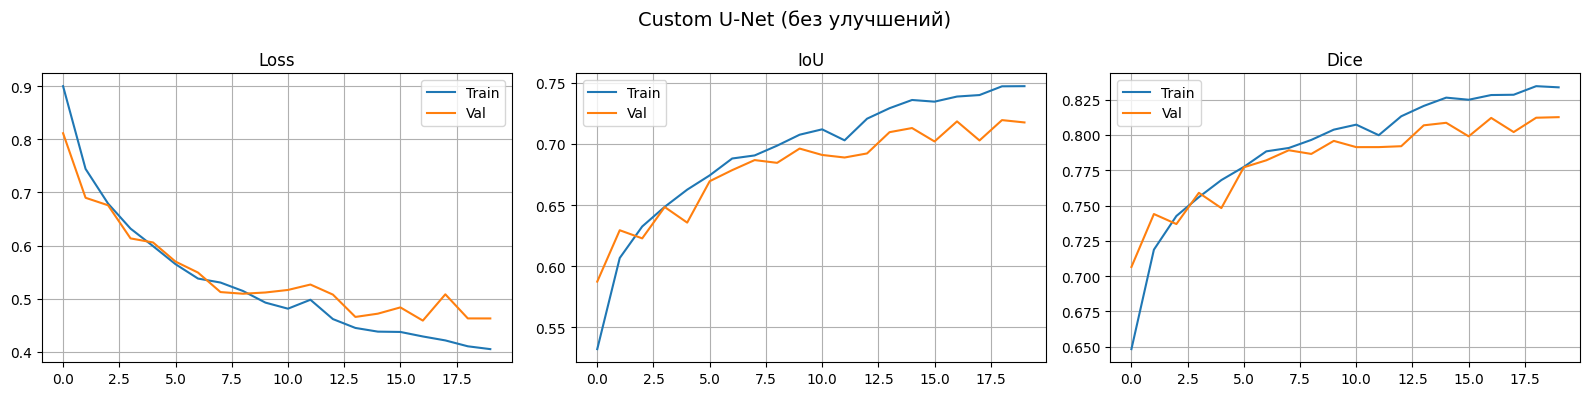

In [23]:
NUM_EPOCHS = 20
tf = get_base_transforms(IMG_SIZE)
dl = get_dataloaders(DATA_DIR, batch_size=BATCH_SIZE, img_size=IMG_SIZE,
                     transform={"train": tf, "val": tf},
                     val_split=0.15, test_split=0.1, random_state=RANDOM_STATE)

criterion = CombinedLoss(dice_loss, bce_loss)
opt = torch.optim.Adam(model_custom.parameters(), lr=1e-4)
sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", patience=3, factor=0.5)

hist1 = train_model(model_custom, dl, criterion, opt, sch, DEVICE, NUM_EPOCHS,
                    save_dir="../results/custom_model", model_name="custom_unet_base")
plot_history(hist1, "Custom U-Net (без улучшений)")

In [34]:
ce = CombinedLoss(dice_loss, bce_loss)
baseline = pd.read_csv("../results/baseline/baseline_results.csv")

model_custom.load_state_dict(torch.load("../results/custom_model/custom_unet_base_best.pth", weights_only=True))
m = evaluate(model_custom, dl["test"], ce, DEVICE)
cb = pd.DataFrame([{"Модель": "Custom U-Net (base)", "IoU": m["iou"], "Dice": m["dice"],
                    "Pixel Acc": m["pixel_acc"], "Loss": m["loss"]}])
print("\n=== Бейзлайн SMP vs Своя модель ===")
print(pd.concat([baseline, cb], ignore_index=True).to_string(index=False))


=== Бейзлайн SMP vs Своя модель ===
             Модель      IoU     Dice  Pixel Acc     Loss
      Unet+ResNet34 0.806447 0.876771   0.942823 0.304790
       MAnet+MiT-B2 0.821588 0.885775   0.948361 0.271879
Custom U-Net (base) 0.744615 0.834657   0.917605 0.401908


### 4e. **Вывод по имплементированной модели**

Custom U-Net (IoU=0.745) уступает SMP-моделям на 0.06–0.08. Ожидаемо: SMP-модели используют предобученные на ImageNet энкодеры, а кастомная модель учится с нуля. Кроме того, уменьшенная архитектура (7.8M параметров vs 24M у Unet+ResNet34) ограничивает ёмкость модели.

### 4f. Добавление техник из улучшенного бейзлайна (п.3c)
#### Улучшения: аугментации (HorizontalFlip, VerticalFlip, RandomRotate90, RandomBrightnessContrast)

/home/nikki/water-body-segmentation/notebooks/../src/dataset.py:92: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),


Train: 2130 | Val: 426 | Test: 285

Epoch 1/40


  Train — loss:1.0485 IoU:0.4798 Dice:0.6034
  Val   — loss:0.8233 IoU:0.5703 Dice:0.6849
  ✓ Saved (IoU: 0.5703)

Epoch 2/40


  Train — loss:0.9019 IoU:0.5443 Dice:0.6645
  Val   — loss:0.7787 IoU:0.5933 Dice:0.7054
  ✓ Saved (IoU: 0.5933)

Epoch 3/40


  Train — loss:0.8486 IoU:0.5592 Dice:0.6794
  Val   — loss:0.7477 IoU:0.6161 Dice:0.7285
  ✓ Saved (IoU: 0.6161)

Epoch 4/40


...

  Train — loss:0.5188 IoU:0.6897 Dice:0.7875
  Val   — loss:0.4506 IoU:0.7269 Dice:0.8197
  ✓ Saved (IoU: 0.7269)

Epoch 37/40


  Train — loss:0.5124 IoU:0.6968 Dice:0.7921
  Val   — loss:0.4520 IoU:0.7251 Dice:0.8173

Epoch 38/40


  Train — loss:0.4971 IoU:0.7005 Dice:0.7959
  Val   — loss:0.4576 IoU:0.7193 Dice:0.8114

Epoch 39/40


  Train — loss:0.4938 IoU:0.7012 Dice:0.7960
  Val   — loss:0.4724 IoU:0.7151 Dice:0.8088

Epoch 40/40


  Train — loss:0.5020 IoU:0.7013 Dice:0.7960
  Val   — loss:0.4538 IoU:0.7244 Dice:0.8152


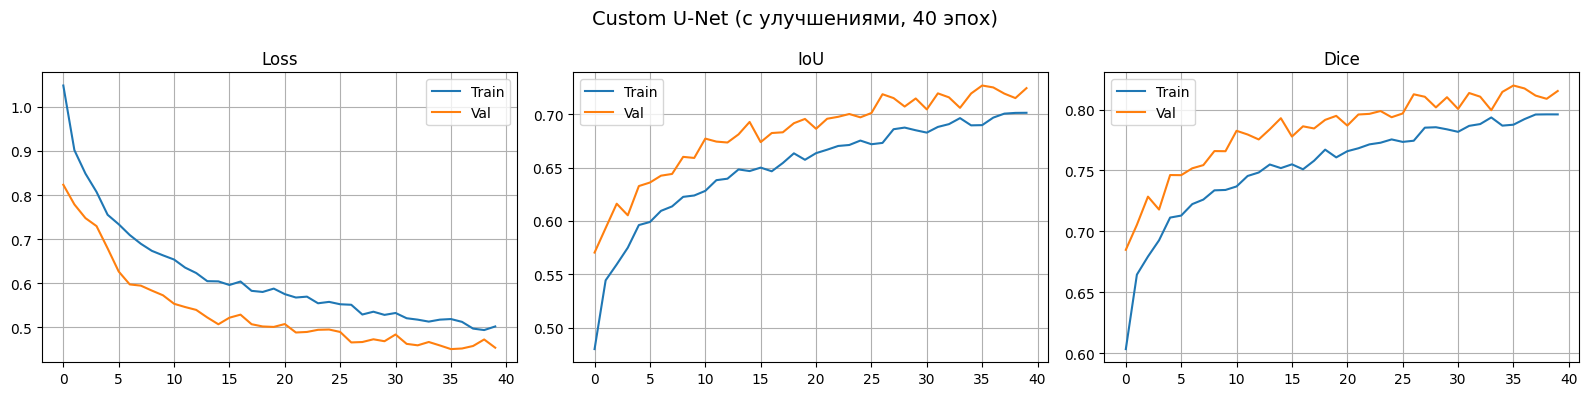

In [35]:
train_tf, val_tf = get_augmented_transforms(IMG_SIZE)
dl_aug = get_dataloaders(DATA_DIR, batch_size=BATCH_SIZE, img_size=IMG_SIZE,
                         transform={"train": train_tf, "val": val_tf},
                         val_split=0.15, test_split=0.1, random_state=RANDOM_STATE)

model_custom_imp = CustomUNet(
    in_channels=3, out_channels=1,
    features=[32, 64, 128, 256]
).to(DEVICE)

criterion = CombinedLoss(dice_loss, bce_loss)
optimizer = torch.optim.Adam(model_custom_imp.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

hist_custom_imp = train_model(model_custom_imp, dl_aug, criterion, optimizer, scheduler,
                              DEVICE, 40, save_dir="../results/custom_model",
                              model_name="custom_unet_improved")
plot_history(hist_custom_imp, "Custom U-Net (с улучшениями, 40 эпох)")

### 4h–4i. Оценка и сравнение с п.3

In [37]:
model_custom_imp.load_state_dict(
    torch.load("../results/custom_model/custom_unet_improved_best.pth", weights_only=True))
m_ci = evaluate(model_custom_imp, dl_aug["test"], ce, DEVICE)

# Сравнение всех моделей
final = pd.DataFrame([
    {"Модель": "Unet+ResNet34 (бейзлайн)",    "IoU": 0.806447, "Dice": 0.876771, "Pixel Acc": 0.942823},
    {"Модель": "MAnet+MiT-B2 (бейзлайн)",     "IoU": 0.821588, "Dice": 0.885775, "Pixel Acc": 0.948361},
    {"Модель": "Улучшенный бейзлайн (п.3c)",   "IoU": m_imp["iou"], "Dice": m_imp["dice"], "Pixel Acc": m_imp["pixel_acc"]},
    {"Модель": "Custom U-Net (без улучш.)",    "IoU": 0.744615, "Dice": 0.834657, "Pixel Acc": 0.917605},
    {"Модель": "Custom U-Net (с улучш.)",      "IoU": m_ci["iou"], "Dice": m_ci["dice"], "Pixel Acc": m_ci["pixel_acc"]},
])
print("\n=== ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===")
print(final.to_string(index=False))
final.to_csv("../results/custom_model/final_comparison.csv", index=False)


=== ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===
                    Модель      IoU     Dice  Pixel Acc
  Unet+ResNet34 (бейзлайн) 0.806447 0.876771   0.942823
   MAnet+MiT-B2 (бейзлайн) 0.821588 0.885775   0.948361
Улучшенный бейзлайн (п.3c) 0.811651 0.877352   0.945467
 Custom U-Net (без улучш.) 0.744615 0.834657   0.917605
   Custom U-Net (с улучш.) 0.745506 0.835964   0.918742


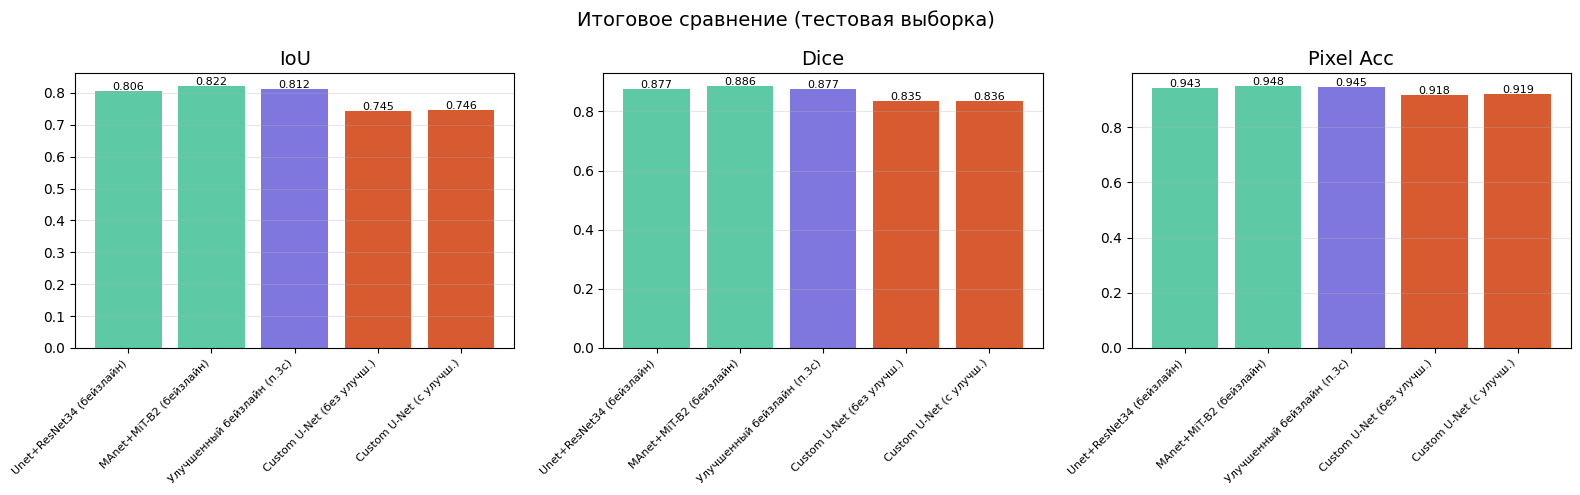

In [ ]:
# Итоговый график
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#5DCAA5", "#5DCAA5", "#7F77DD", "#D85A30", "#D85A30"]
for ax, metric in zip(axes, ["IoU", "Dice", "Pixel Acc"]):
    bars = ax.bar(range(len(final)), final[metric], color=colors)
    ax.set_title(metric, fontsize=14)
    ax.set_xticks(range(len(final)))
    ax.set_xticklabels(final["Модель"].tolist(), rotation=45, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                f"{b.get_height():.3f}", ha="center", fontsize=8)
plt.suptitle("Итоговое сравнение (тестовая выборка)", fontsize=14)
plt.tight_layout(); plt.show()

### 4i–4j. **Итоговые выводы**

Аугментации дали минимальный прирост для Custom U-Net (+0.001 IoU). Основное узкое место — отсутствие предобученного энкодера, а не недостаток аугментаций. Лучшая модель — MAnet+MiT-B2 (IoU=0.822). Для практического применения рекомендуется использовать SMP-модели с предобученными энкодерами, так как имплементация с нуля при ограниченных данных (~2100 train) значительно уступает в качестве.